In [1]:
# ── Imports ──
# Henderson V1 — same architecture as Witt V10
# 8 features: era, park_factor, pitcher_r, is_home,
#             avg_exit_velo_15, barrel_rate_15, hard_hit_rate_15, hr_zone_rate_15
# Key differences from Witt:
#   - Henderson bats LEFT — pitcher_r expected > 1 (platoon advantage vs RHP)
#   - Camden Yards (team_id 110) — solid HR park, park factor 103
#   - Well-rounded hitter, context-sensitive profile — good model candidate
#   - 3 full seasons of data (2022 partial, 2023, 2024, 2025)
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine


In [2]:
# ── Load base dataset from database ──
# Henderson player_id = 683002
PLAYER_ID = 683002

with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM player_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 110
                 ELSE w.opponent_id
            END = pf.team_id
        )
        WHERE w.player_id = :pid
        ORDER BY w.date
    """), conn, params={"pid": PLAYER_ID})

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb', 'era']].head(10))


Base dataset: (509, 12)
         date  hr  tb   era
0  2022-08-31   1   5  3.17
1  2022-09-01   0   1  3.02
2  2022-09-02   0   4  2.28
3  2022-09-03   0   1  5.66
4  2022-09-04   0   0  5.28
5  2022-09-05   0   1  3.14
6  2022-09-05   0   1  5.08
7  2022-09-06   0   1  4.67
8  2022-09-07   0   0  2.48
9  2022-09-09   0   3  6.03


In [3]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"\n(Witt: 16.0%, Schwarber: 25.7% for comparison)")


HR distribution:
hr
0    421
1     86
2      2
Name: count, dtype: int64

Games with 0 HR:  0.827
Games with 1+ HR: 0.173 (17.3% of games)
Games with 2+ HR: 0.004

Break-even American odds: -21

(Witt: 16.0%, Schwarber: 25.7% for comparison)


In [4]:
# ── Pull Statcast data via pybaseball ──
# Henderson player_id = 683002
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=683002)
print(f"Statcast raw: {statcast_raw.shape}")


Pulling Statcast data...
Gathering Player Data
Statcast raw: (8732, 118)


In [5]:
# ── Aggregate Statcast to game level ──
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle band — where balls most frequently leave the park
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))

Game-level Statcast: (504, 9)
    game_date  barrel_rate  hr_zone_rate
0  2022-08-31        0.125           0.0
1  2022-09-01        0.000           0.2
2  2022-09-02        0.000           0.0
3  2022-09-03        0.000           0.2
4  2022-09-04        0.000           0.0
5  2022-09-05        0.000           0.0
6  2022-09-06        0.000           0.2
7  2022-09-07        0.000           0.0
8  2022-09-09        0.500           0.0
9  2022-09-10        0.000           0.2


In [6]:
# ── Rolling Statcast features — 15-day window ──
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))

     game_date  barrel_rate_15  hr_zone_rate_15
0   2022-08-31             NaN              NaN
1   2022-09-01             NaN              NaN
2   2022-09-02             NaN              NaN
3   2022-09-03             NaN              NaN
4   2022-09-04             NaN              NaN
5   2022-09-05             NaN              NaN
6   2022-09-06             NaN              NaN
7   2022-09-07        0.017857         0.085714
8   2022-09-09        0.015625         0.075000
9   2022-09-10        0.069444         0.066667
10  2022-09-11        0.062500         0.080000
11  2022-09-13        0.056818         0.072727
12  2022-09-14        0.052083         0.085185
13  2022-09-16        0.067308         0.078632
14  2022-09-17        0.080357         0.073016
15  2022-09-18        0.075000         0.068148
16  2022-09-19        0.066667         0.068148
17  2022-09-20        0.077778         0.065926
18  2022-09-21        0.087302         0.075450
19  2022-09-22        0.087302         0

In [7]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())

After merge: (509, 17)
avg_exit_velo_15    22
barrel_rate_15      22
hr_zone_rate_15     22
dtype: int64


In [8]:
# ── Feature engineering ──
df = df.sort_values('date').reset_index(drop=True)

df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Henderson bats left — pitcher_r expected > 1 (platoon advantage vs RHP)

# Drop rows missing Statcast rolling features only
df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")


Model dataset: (487, 19)


In [9]:
# ── Define features and binary target ──
# Henderson V1 — 8 features (no k_per_9, matching Schwarber V2 baseline)
# Will add k_per_9 in V2 if signs are clean
FEATURES = [
    # Henderson contact quality
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',
    # Game context
    'is_home',
    'pitcher_r',
    # Pitcher
    'era',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")
print(f"\n(Witt: 0.160, Schwarber: 0.257 for comparison)")


Features: 8
Dataset: (487, 8)
HR rate: 0.170 (83 HR games out of 487)

(Witt: 0.160, Schwarber: 0.257 for comparison)


In [10]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [11]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.830
Break-even odds for HR prop: -21


In [12]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))

Best C:        0.001
Best CV AUC:   0.529

 param_C  mean_test_score  std_test_score
   0.001           0.5290          0.0866
   0.010           0.5290          0.0894
   0.050           0.5274          0.0970
   0.100           0.5281          0.0997
   0.250           0.5244          0.1018
   0.500           0.5240          0.1014
   1.000           0.5240          0.1026
   2.000           0.5232          0.1026
   5.000           0.5234          0.1017
  10.000           0.5238          0.1020


In [13]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean +/- std: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"ACC mean +/- std: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nHenderson V1 CV AUC: {cv_auc.mean():.3f}")
print(f"Witt V10 CV AUC:     0.567")
print(f"Schwarber V2 CV AUC: 0.527")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")


CV AUC per fold:  [np.float64(0.363), np.float64(0.585), np.float64(0.552), np.float64(0.608), np.float64(0.537)]
CV ACC per fold:  [np.float64(0.79), np.float64(0.716), np.float64(0.827), np.float64(0.901), np.float64(0.889)]

AUC mean +/- std: 0.529 +/- 0.087
ACC mean +/- std: 0.825 +/- 0.068

Baseline ACC:     0.830
Improvement:      -0.005

Henderson V1 CV AUC: 0.529
Witt V10 CV AUC:     0.567
Schwarber V2 CV AUC: 0.527

(AUC > 0.55 = meaningful signal for sports betting)


In [14]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.598
In-sample ACC:  0.830
CV AUC:         0.529

Gap (in-sample - CV AUC): 0.069
(smaller gap = less overfitting)

Mean P(HR):     0.170
Actual HR rate: 0.170


In [15]:
# ── Calibration table ──
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"V6 spread:              0.185")
print(f"V5 spread:              ~0.12")
print("\n(larger spread = better discrimination between HR and non-HR games)")

          mean_predicted  actual_rate   n
pred_bin                                 
0                  0.165        0.082  98
1                  0.168        0.175  97
2                  0.170        0.144  97
3                  0.172        0.227  97
4                  0.175        0.224  98

Spread (bin 4 - bin 0): 0.142
V6 spread:              0.185
V5 spread:              ~0.12

(larger spread = better discrimination between HR and non-HR games)


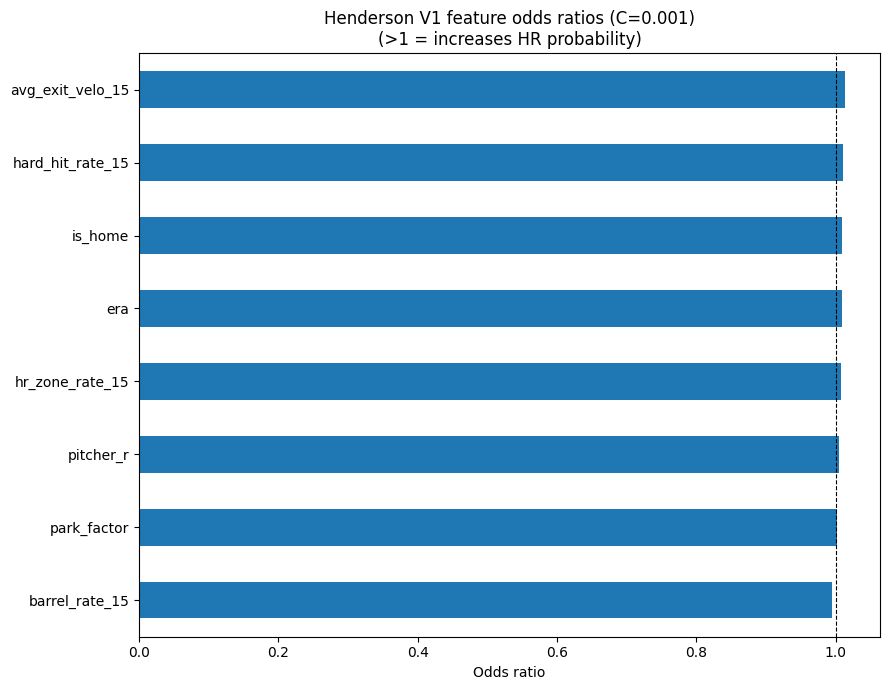


Odds ratios:
barrel_rate_15      0.995
park_factor         1.001
pitcher_r           1.004
hr_zone_rate_15     1.008
era                 1.009
is_home             1.009
hard_hit_rate_15    1.010
avg_exit_velo_15    1.013
dtype: float64


In [16]:
# ── Feature odds ratios ──
# Expected directions:
#   era        > 1 — higher ERA = worse pitcher = more HRs
#   park_factor > 1 — Camden Yards solid HR park
#   pitcher_r  > 1 — Henderson bats left, platoon advantage vs RHP
#   is_home    > 1 — home field advantage at Camden Yards
#   Statcast   uncertain — watch whether hot streaks persist or revert
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'Henderson V1 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))


In [17]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
467 2025-09-07  0.164810           507  ❌ No HR
468 2025-09-09  0.164989           506  ❌ No HR
469 2025-09-10  0.163581           511  ❌ No HR
470 2025-09-11  0.165166           505  ❌ No HR
471 2025-09-12  0.162901           514  ❌ No HR
472 2025-09-13  0.163824           510  ❌ No HR
473 2025-09-14  0.163099           513  ❌ No HR
474 2025-09-15  0.161669           519  ❌ No HR
475 2025-09-16  0.164857           507  ❌ No HR
476 2025-09-17  0.162704           515  ❌ No HR
477 2025-09-18  0.164613           507  ❌ No HR
478 2025-09-19  0.167044           499  ❌ No HR
479 2025-09-20  0.165133           506  ❌ No HR
480 2025-09-21  0.168551           493  ❌ No HR
481 2025-09-23  0.169710           489  ❌ No HR
482 2025-09-24  0.170790           486  ❌ No HR
483 2025-09-25  0.170847           485  ❌ No HR
484 2025-09-26  0.170448           487  ❌ No HR
485 2025-09-27  0.169445           4

In [18]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/henderson_hr_logistic_v1_model.pkl')
joblib.dump(scaler, '../models/henderson_hr_logistic_v1_scaler.pkl')
print("Saved:")
print("  models/henderson_hr_logistic_v1_model.pkl")
print("  models/henderson_hr_logistic_v1_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Saved:
  models/henderson_hr_logistic_v1_model.pkl
  models/henderson_hr_logistic_v1_scaler.pkl

Best C: 0.001
Features (8): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'pitcher_r', 'era', 'park_factor']
